In [1]:
from utils import get_codebook
from utils import get_questions_list, get_codebook_subset, codebook_to_json, get_survey_questionnaire, convert_textdf_to_numeric_response_df
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import string

from autogen.agentchat import UserProxyAgent, AssistantAgent, GroupChat, GroupChatManager
from autogen.coding import LocalCommandLineCodeExecutor
from dotenv import load_dotenv
from openai import AzureOpenAI
from datetime import datetime
load_dotenv()

flaml.automl is not available. Please install flaml[automl] to enable AutoML functionalities.


True

In [2]:
transcripts_dir = os.path.join(os.getcwd(),  'transcripts')
if not os.path.exists(transcripts_dir):
    os.makedirs(transcripts_dir)

phone_survey_dir           = os.path.join(os.getcwd(),        'phone-survey-data')
numeric_survey_file        = os.path.join(phone_survey_dir,   'numeric_full_phone_survey_01_April_30_covid_impact_survey.csv')
text_survey_file           = os.path.join(phone_survey_dir,   'clean_text_full_phone_survey_01_April_30_covid_impact_survey.csv')
april_transcript_data_file = os.path.join(phone_survey_dir,   'april_transcript_survey.csv')
codebook_json_file         = os.path.join(transcripts_dir,    'codebook.json')
numeric_survey_df          = pd.read_csv(numeric_survey_file)
text_survey_df             = pd.read_csv(text_survey_file)

In [3]:
survey_question_codes = [
                         'AGE7',
                         'GENDER',
                         'RACETH',
                         'HHINCOME',
                         'EDUCATION',
                         'HHSIZE1',
                         'HH01S',
                         'HH25S',
                         'HH612S',
                         'HH1317S',
                         'HH18OVS',
                         'SOC2A', 
                         'SOC2B',    
                         'SOC5A', 
                         'SOC5B', 
                         'SOC5C', 
                         'SOC5D', 
                         'SOC5E',
                         'ECON1',
                         'PHYS8',
                         'PHYS4',
                         'PHYS5',
                         'PHYS1B', 
                         'PHYS1C', 
                         'PHYS1D', 
                         'PHYS1E', 
                         'PHYS1F', 
                         'PHYS1G', 
                         'PHYS1H', 
                         'PHYS1I', 
                         'PHYS1J',
                         'PHYS11', 
                         'PHYS11_TEMP'
                        ]
print(f"Total number of questions: {len(survey_question_codes)}")
assert len(survey_question_codes) == 33, "There should be 33 survey questions."

Total number of questions: 33


In [4]:
race_options = [ 'White', 
'Black or African American', 
'American Indian or Alaska Native',
'Asian Indian',
'Chinese',
'Filipino', 
'Japanese', 
'Korean', 
'Vietnamese', 
'Other Asian', 
'Native Hawaiian', 
'Guamanian or Chamorro', 
'Samoan',
'Other Pacific Islander', 
'Some other race',
'REFUSED'
]

education_options = [ 'No formal education', 
'1st, 2nd, 3rd, or 4th grade',   
'5th or 6th grade',
'7th or 8th grade',
'9th grade', 
'10th grade', 
'11th grade', 
'12th grade - NO DIPLOMA', 
'High school graduate - high school diploma or the equivalent',
'Some college, no degree',
'Associate degree', 
"Bachelor's degree",
"Master's degree",
'Professional or Doctorate degree',
'REFUSED'
]

def adapt_QA_for_phone_survey(codebook):
    # set right question for age
    codebook['AGE7'].set_question("What is your current age?")

    #set question and options for gender
    codebook['GENDER'].set_question("Are you male or female?")
    codebook['GENDER'].remove_response("Unknown")
    codebook['GENDER'].remove_response("Not sure")

    #set necessary questions and answers for race
    codebook['RACETH'].set_question("What race or races you consider yourself to be? You can say multiple races.")
    codebook['RACETH'].clear_response_mappings()
    for i in range(len(race_options)):
        ans_id = 99 if race_options[i] == 'REFUSED' else i+1
        codebook['RACETH'].set_answers(ans_id, race_options[i])

    #set question for income
    codebook['HHINCOME'].set_question("What was your total HOUSEHOLD income in 2019?")

    #set necessary questions and answers for education
    codebook['EDUCATION'].set_question("What is the highest level of school you have completed?")
    codebook['EDUCATION'].clear_response_mappings()
    for i in range(len(education_options)):
        ans_id = 99 if education_options[i] == 'REFUSED' else i+1
        codebook['EDUCATION'].set_answers(ans_id, education_options[i])
    

    #set question for household size questions
    codebook['HHSIZE1'].set_question("Including yourself, how many persons currently live in your household at least 50 percent of the time? Please include any children as well as adults.")
    codebook['HHSIZE1'].remove_response("DON'T KNOW")
    codebook['HH01S'].set_question("How many persons currently living in your household, including yourself, are 0-1 years old?")
    codebook['HH25S'].set_question("How many persons currently living in your household, including yourself, are 2-5 years old?")
    codebook['HH612S'].set_question("How many persons currently living in your household, including yourself, are 6-12 years old?")
    codebook['HH1317S'].set_question("How many persons currently living in your household, including yourself, are 13-17 years old?")
    codebook['HH18OVS'].set_question("How many persons currently living in your household, including yourself, are 18+ years old?")
    
    #add numeric answer option to people counts in house
    for code in ['HH01S', 'HH25S', 'HH612S', 'HH1317S', 'HH18OVS', 'PHYS11_TEMP']:
        codebook[code].set_answers(1, 'Numeric Value')


    codebook['SOC5A'].set_question("In the past 7 days, how often have you felt nervous, anxious, or on edge?")
    codebook['SOC5B'].set_question("In the past 7 days, how often have you felt depressed?")
    codebook['SOC5C'].set_question("In the past 7 days, how often have you felt lonely?")
    codebook['SOC5D'].set_question("In the past 7 days, how often have you felt hopeless about the future?")
    codebook['SOC5E'].set_question("In the past 7 days, how often have you had physical reactions such as sweating, trouble breathing, nausea or a pounding heart when thinking about your experience with the coronavirus pandemic?")


    codebook['ECON1'].clear_response_mappings()
    codebook['ECON1'].set_answers(1, '''Yes, I worked for someone else for wages, salary, piece rate, commission, tips, or payments 'in kind,' for example, food or lodging received as payment for work performed''')
    codebook['ECON1'].set_answers(2, '''Yes, I worked as self-employed in my own business, professional practice, or farm''')
    codebook['ECON1'].set_answers(3, '''No, I did not work for pay last week''')
    codebook['ECON1'].set_answers(77, "DON'T KNOW")
    codebook['ECON1'].set_answers(99, "REFUSED")

    
    codebook['PHYS1B'].set_question("Have you experienced chills in the past 7 days, or not?")
    codebook['PHYS1C'].set_question("Have you experienced runny or stuffy nose in the past 7 days, or not?")
    codebook['PHYS1D'].set_question("Have you experienced chest congestion in the past 7 days, or not?")
    codebook['PHYS1E'].set_question("Have you experienced skin rash in the past 7 days, or not?")
    codebook['PHYS1F'].set_question("Have you experienced cough in the past 7 days, or not?")
    codebook['PHYS1G'].set_question("Have you experienced sore throat in the past 7 days, or not?")
    codebook['PHYS1H'].set_question("Have you experienced sneezing in the past 7 days, or not?")
    codebook['PHYS1I'].set_question("Have you experienced muscle or body aches in the past 7 days, or not?")
    codebook['PHYS1J'].set_question("Have you experienced headaches in the past 7 days, or not?")


    codebook['PHYS11_TEMP'].set_question("What is your body temperature?")
    codebook['PHYS11_TEMP'].remove_response("DON'T KNOW")
    codebook['PHYS11_TEMP'].remove_response("OUT OF RANGE")
    
    
    
full_codebook = get_codebook()
codebook = get_codebook_subset(full_codebook, survey_question_codes)
adapt_QA_for_phone_survey(codebook)
codebook_to_json(codebook, codebook_file_name = codebook_json_file, remove_web_options = True)
print(get_survey_questionnaire(codebook))

AGE7 Question 1: What is your current age?
Response Options: 18-24; 25-34; 35-44; 45-54; 55-64; 65-74; 75+; Under 18
GENDER Question 2: Are you male or female?
Response Options: Male; Female; REFUSED
RACETH Question 3: What race or races you consider yourself to be? You can say multiple races.
Response Options: White; Black or African American; American Indian or Alaska Native; Asian Indian; Chinese; Filipino; Japanese; Korean; Vietnamese; Other Asian; Native Hawaiian; Guamanian or Chamorro; Samoan; Other Pacific Islander; Some other race; REFUSED
HHINCOME Question 4: What was your total HOUSEHOLD income in 2019?
Response Options: Under $10,000; $10,000 to under $20,000; $20,000 to under $30,000; $30,000 to under $40,000; $40,000 to under $50,000; $50,000 to under $75,000; $75,000 to under $100,000; $100,000 to under $150,000; $150,000 or more; DON'T KNOW; REFUSED
EDUCATION Question 5: What is the highest level of school you have completed?
Response Options: No formal education; 1st, 2

In [5]:
def plot_response_histograms(text_response_df, codebook, data_codes, colors = None, histogram_type = 'prob'):
    N = len(data_codes)
    fig, axs = plt.subplots(1, N, figsize=(20, 12))
    for i in range(N):
        code = data_codes[i]
        series = text_response_df[code]
        series = series[text_response_df[code] != 'SKIPPED ON WEB']
        hist = series.value_counts()#.sort_index()
        keys = hist.index  
        values = hist.values
        title = codebook[code].get_question()
        if len(title) > 30:
            subtitles = []
            for j in range(0, len(title), 25):
                subtitles.append(title[j:min(len(title), j+25)])
            title = '\n'.join(subtitles)
        
        if histogram_type == 'prob':
            probabilities = hist/hist.sum()
            values = probabilities.values
        axs[i].set_title(title, fontsize=14)
        axs[i].bar(keys, values, color = colors[i])
        axs[i].set_xlabel('Response Options', fontsize=14)
        y_axis_label = 'Probability' if histogram_type == 'prob' else 'Count'
        axs[i].set_ylabel(y_axis_label, fontsize=14)
        axs[i].set_xticks(range(len(keys)))
        xlabels = [k.replace('$', r'\$') for k in keys]
        axs[i].set_xticklabels(xlabels, rotation=90)
        # Set tick label size  
        axs[i].tick_params(axis='x', labelsize=14)   # Set x-axis tick label size  
        axs[i].tick_params(axis='y', labelsize=14)   # Set y-axis tick label size  
        #print(keys)
    
    plt.tight_layout()
    plt.xticks(rotation=90)
    plt.show()

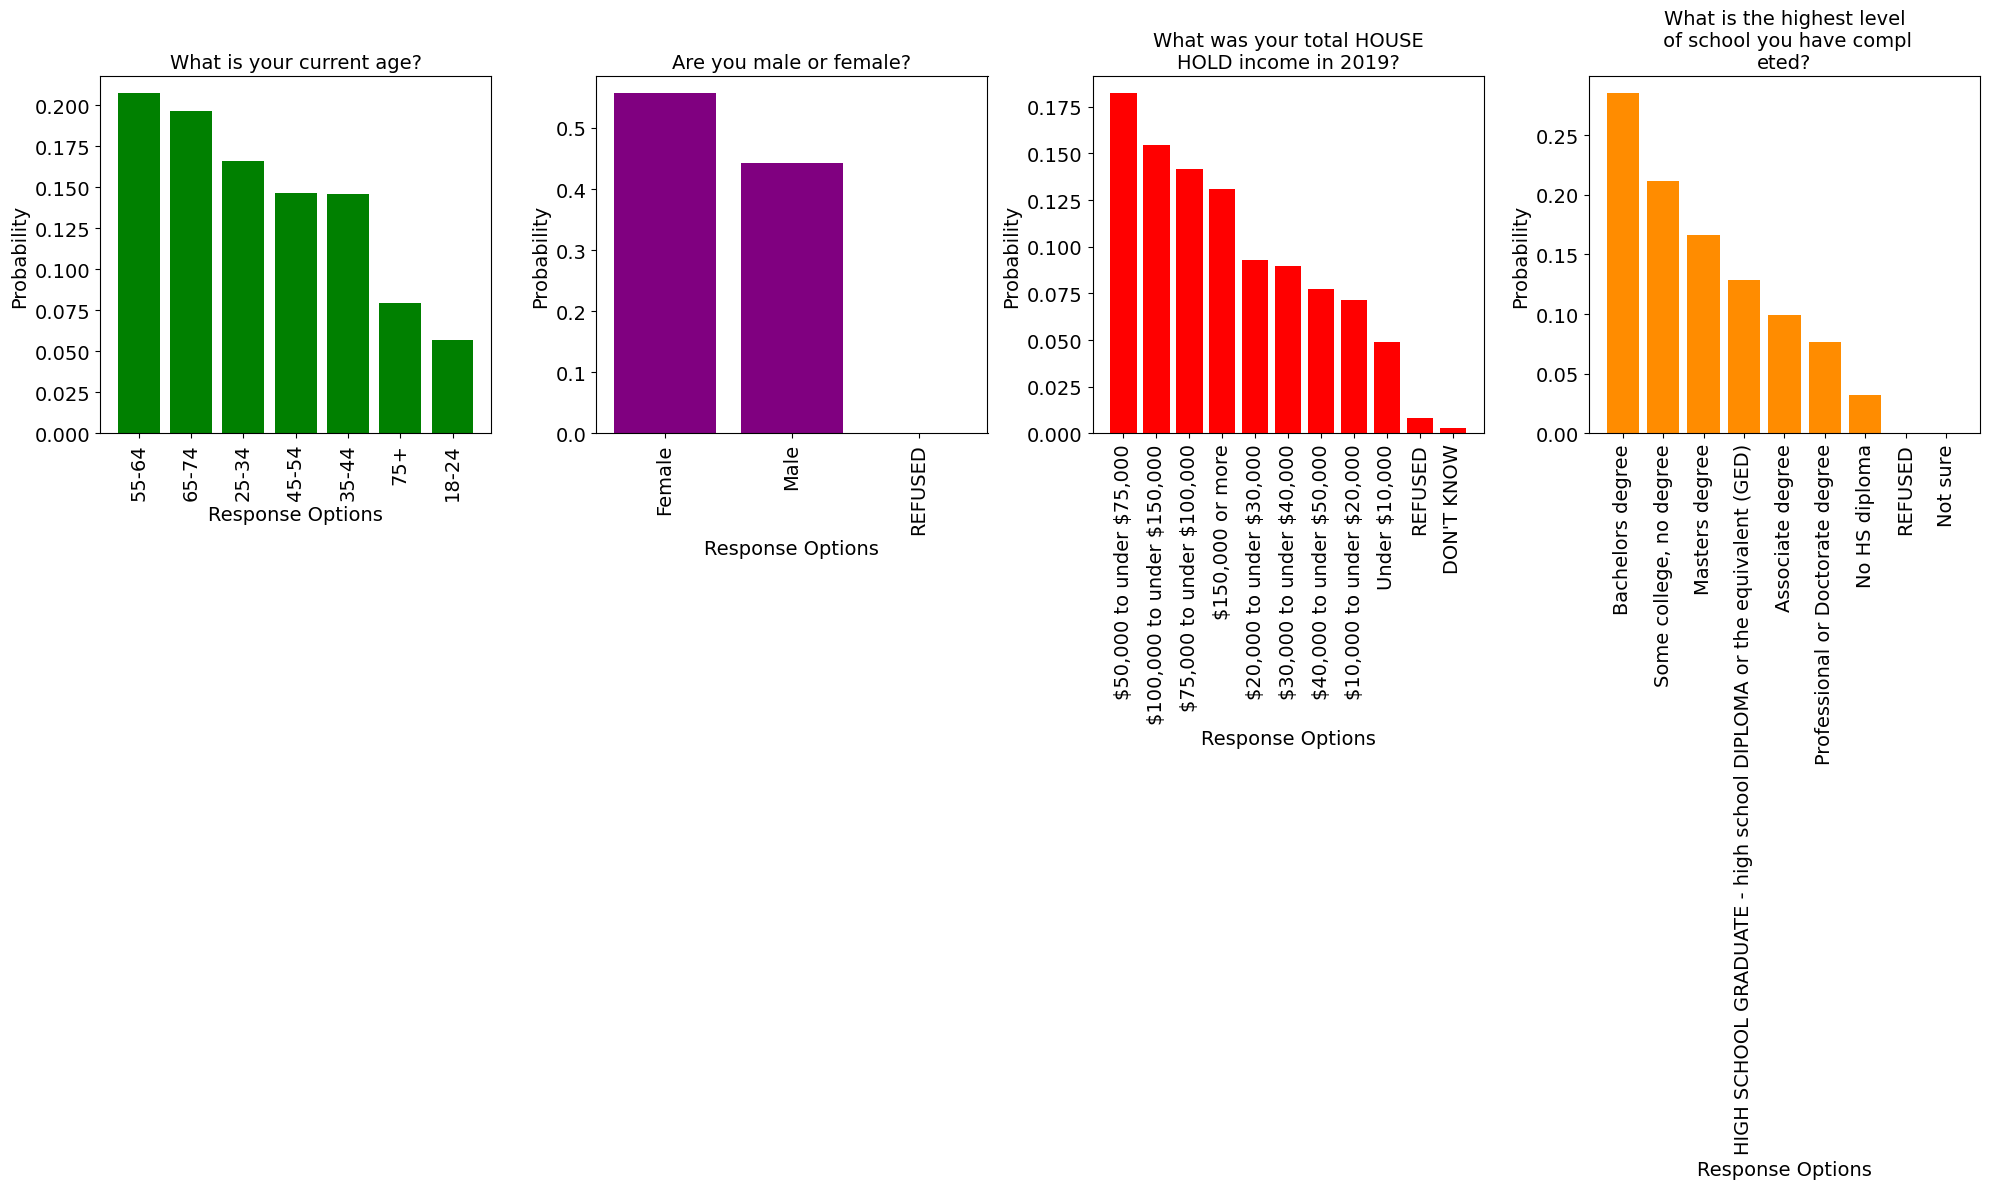

In [6]:
plot_response_histograms(text_survey_df, codebook, [ 'AGE7', 'GENDER','HHINCOME', 'EDUCATION'], colors = ['green', 'purple', 'red', 'darkorange'])

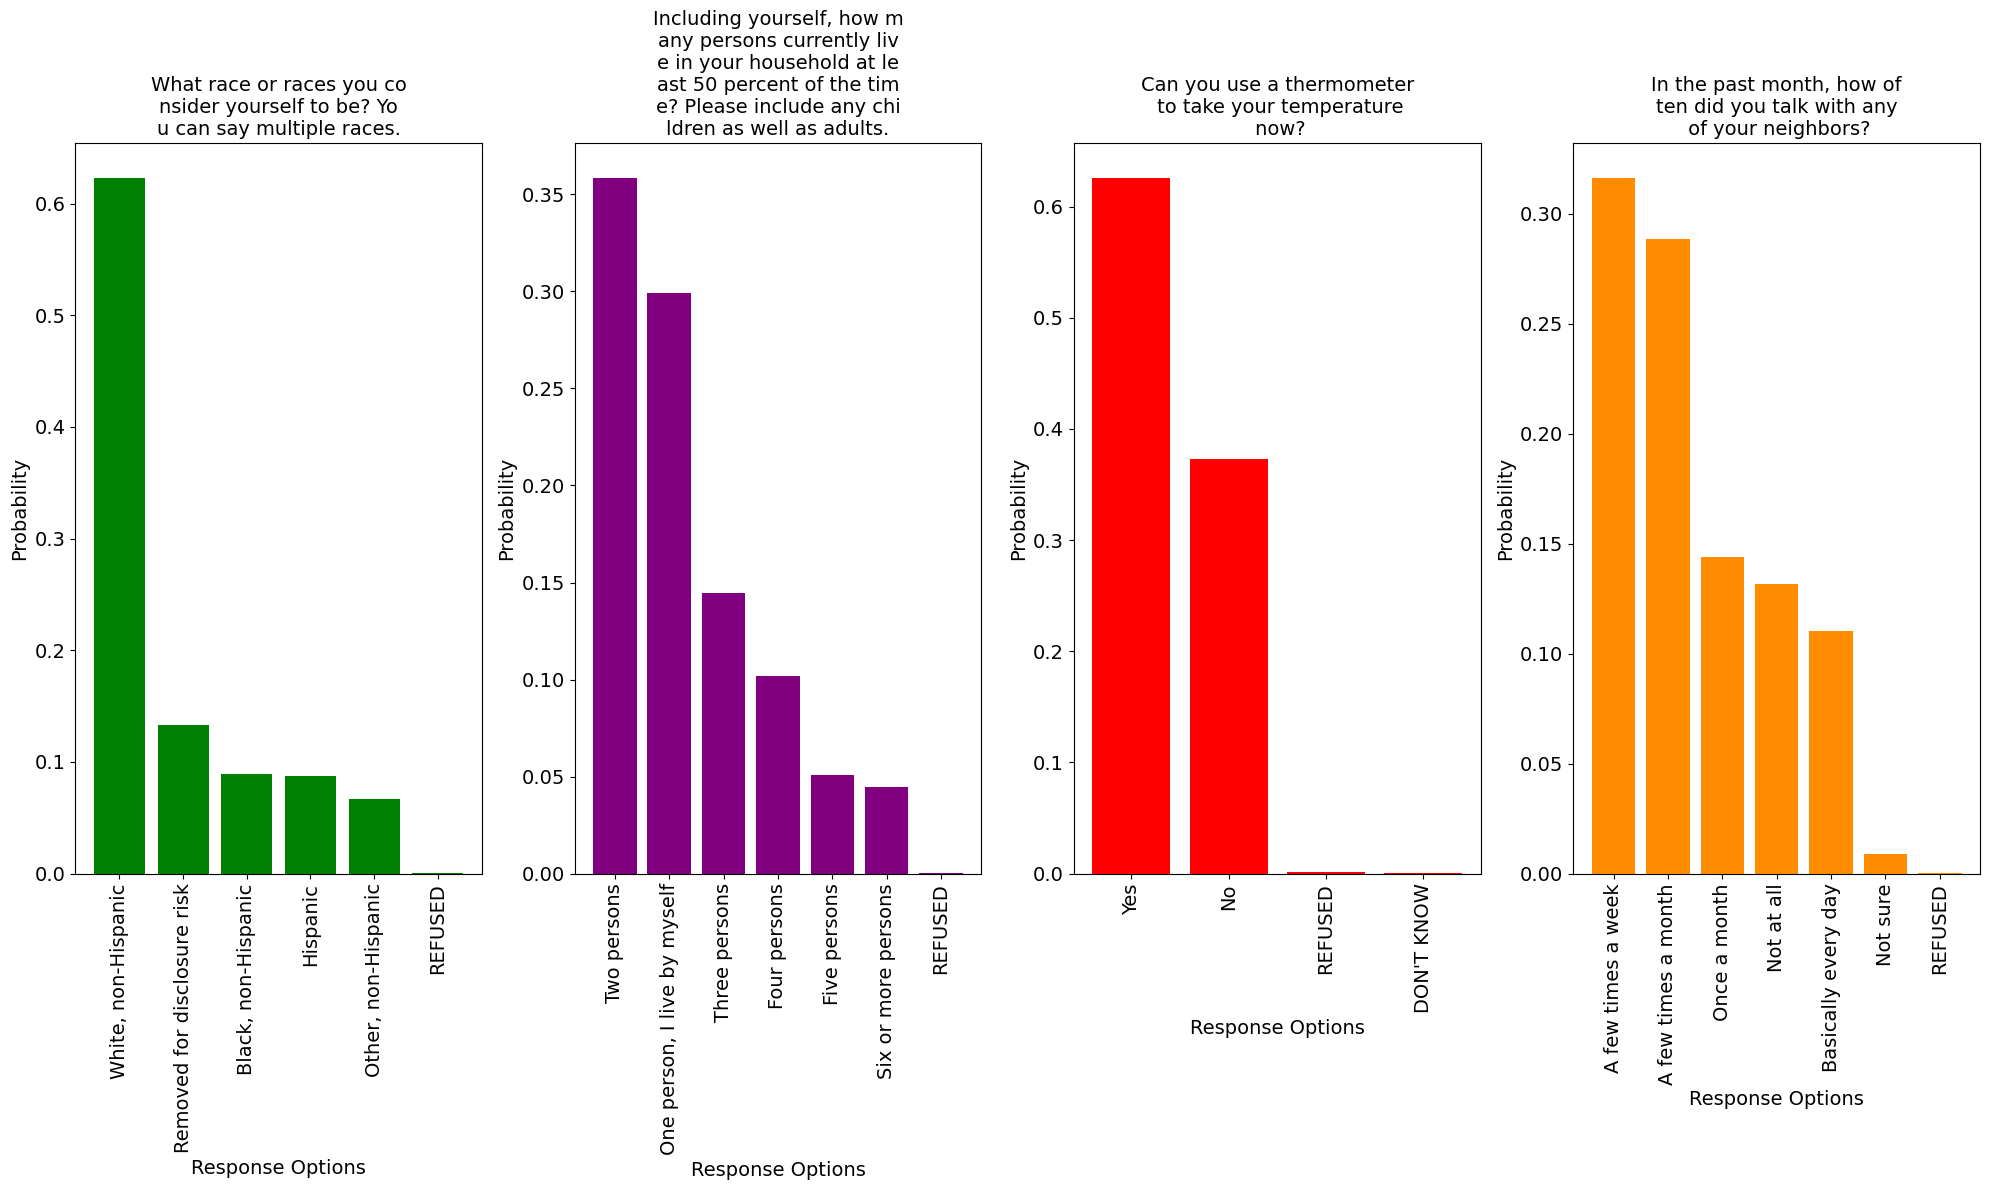

In [7]:
plot_response_histograms(text_survey_df, codebook, [ 'RACETH', 'HHSIZE1', 'PHYS11', 'SOC2A'], colors = ['green', 'purple', 'red', 'darkorange'])

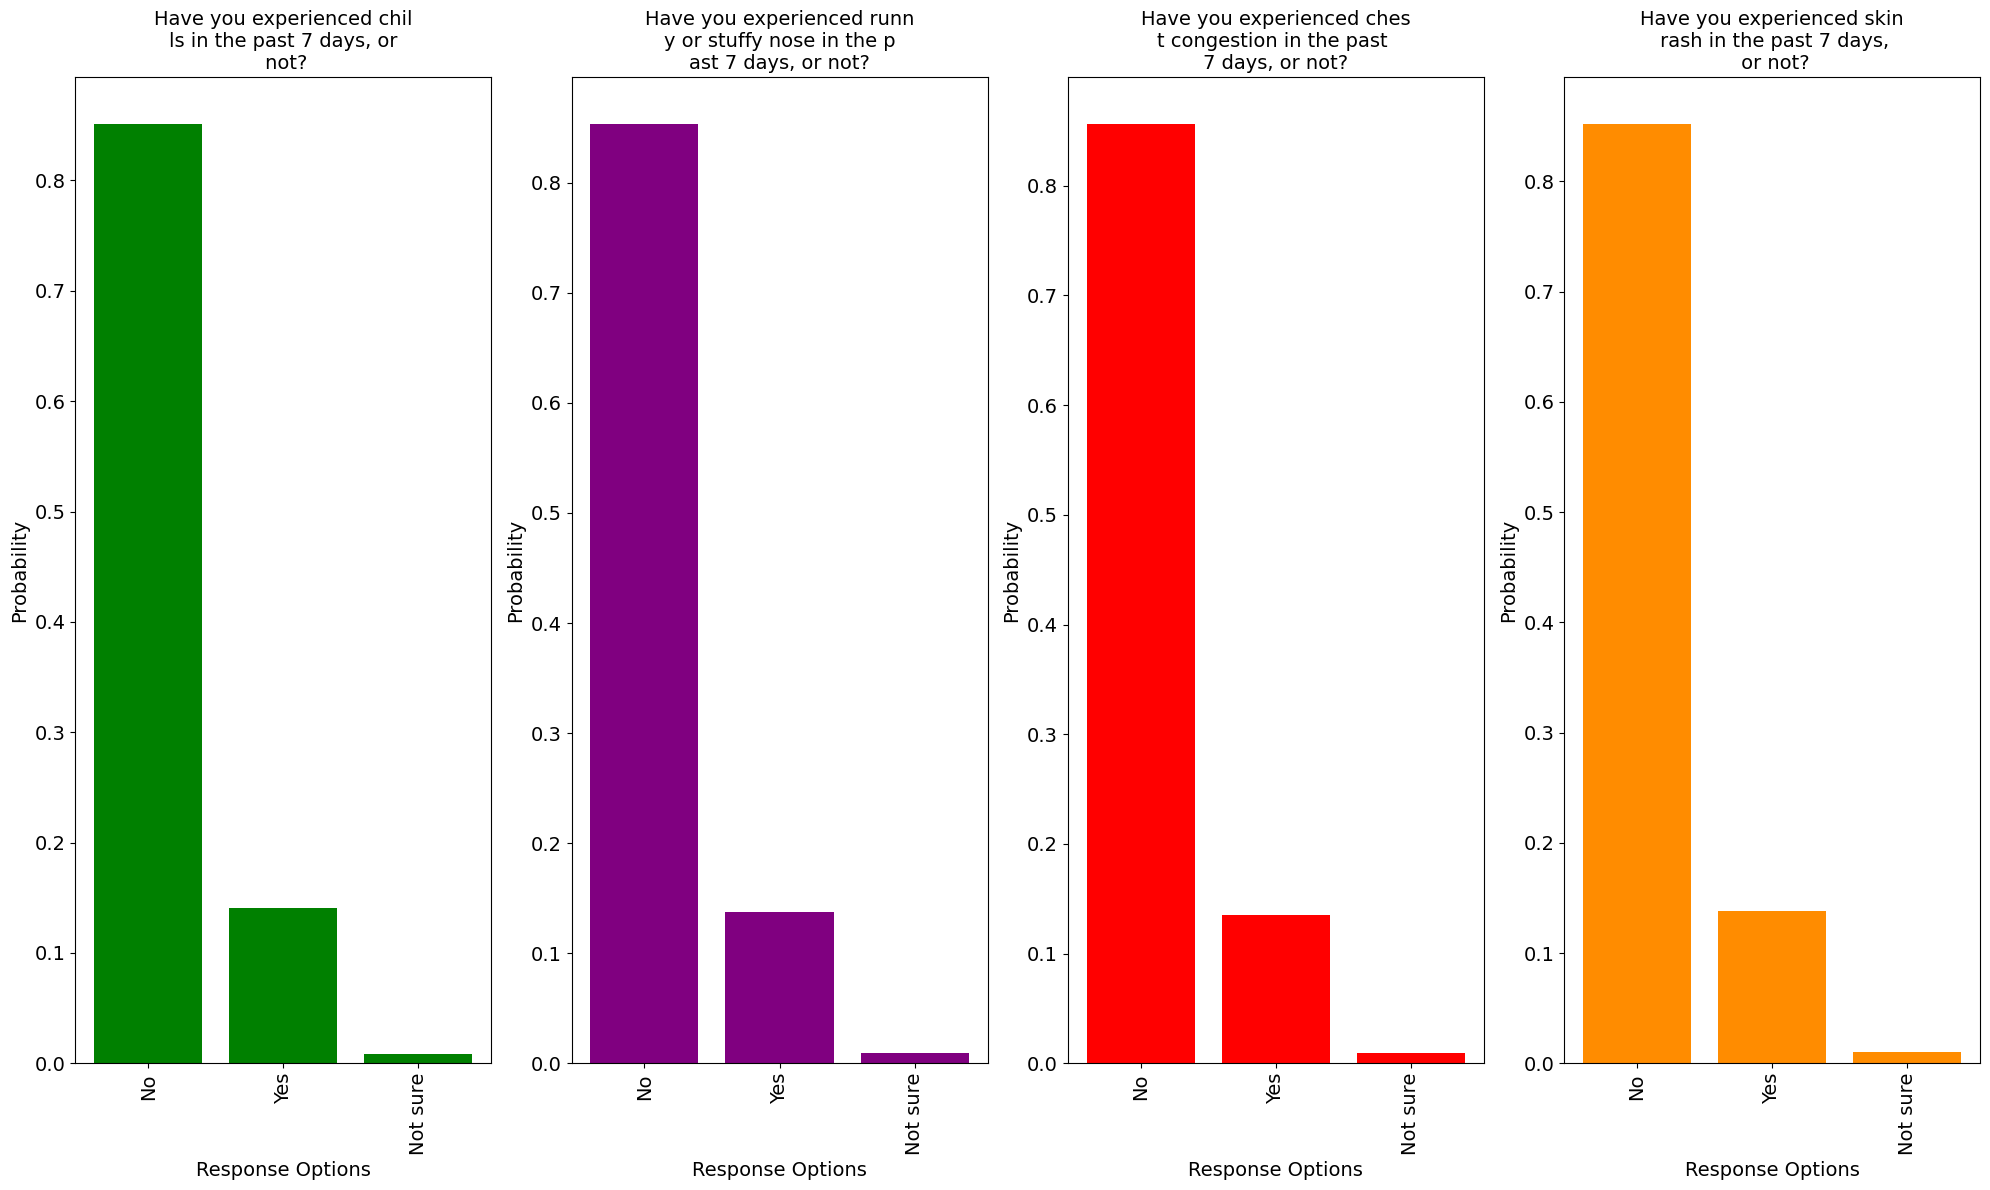

In [8]:
plot_response_histograms(text_survey_df, codebook, [ 'PHYS1B', 'PHYS1C','PHYS1D', 'PHYS1E'], colors = ['green', 'purple', 'red', 'darkorange'])

/var/folders/0f/lqjqfrb16p5gf3__wqf2c94h1tfy6x/T/ipykernel_56574/3762674972.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


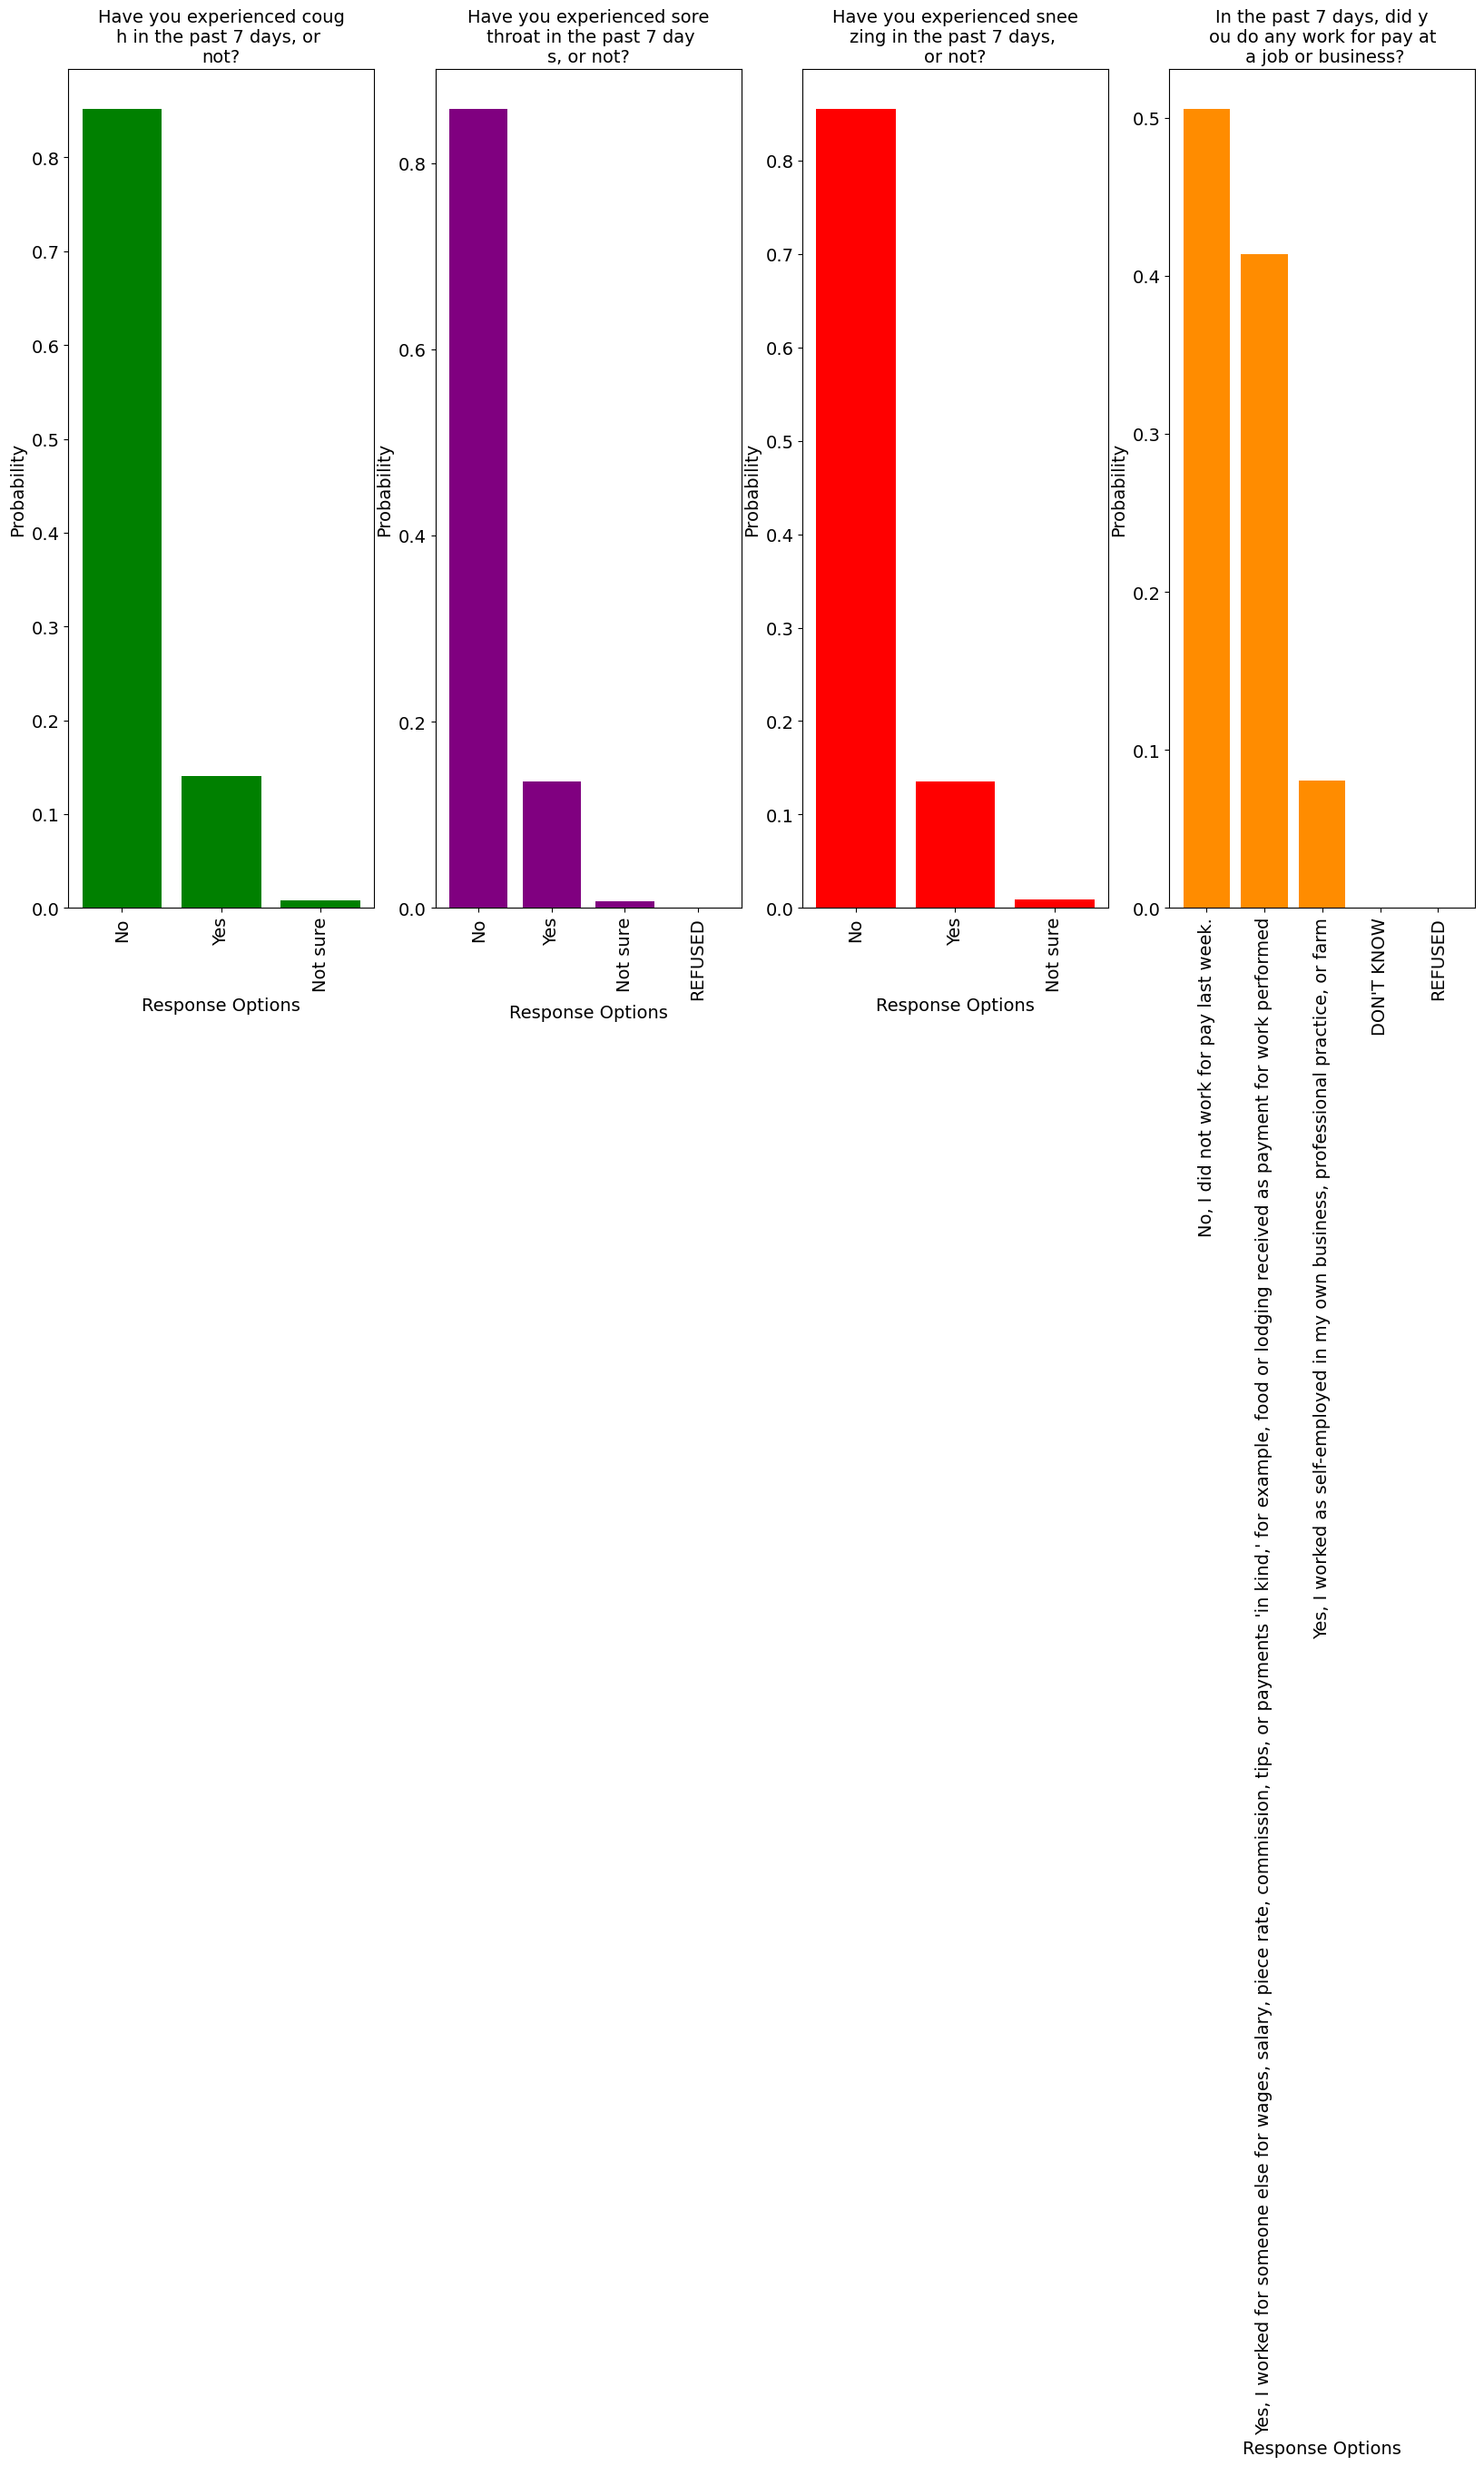

In [9]:
plot_response_histograms(text_survey_df, codebook, [ 'PHYS1F', 'PHYS1G','PHYS1H', 'ECON1'], colors = ['green', 'purple', 'red', 'darkorange'])

In [10]:
sampling_strategy = [
                     ('AGE7',        'survey'),
                     ('GENDER',      'data-driven'),
                     ('RACETH',      'uniform'),
                     ('HHINCOME',    'uniform'),
                     ('EDUCATION',   'uniform'),
                     ('HHSIZE1',     'survey'),
                     ('HH01S',       'survey'),
                     ('HH25S',       'survey'),
                     ('HH612S',      'survey'),
                     ('HH1317S',     'survey'),
                     ('HH18OVS',     'survey'),
                     ('SOC2A',       'data-driven'), 
                     ('SOC2B',       'data-driven'),    
                     ('SOC5A',       'data-driven'), 
                     ('SOC5B',       'data-driven'), 
                     ('SOC5C',       'data-driven'), 
                     ('SOC5D',       'data-driven'), 
                     ('SOC5E',       'data-driven'),
                     ('ECON1',       'data-driven'),
                     ('PHYS8',       'data-driven'),
                     ('PHYS4',       'data-driven'),
                     ('PHYS5',       'data-driven'),
                     ('PHYS1B',      'data-driven'), 
                     ('PHYS1C',      'data-driven'), 
                     ('PHYS1D',      'data-driven'), 
                     ('PHYS1E',      'data-driven'), 
                     ('PHYS1F',      'data-driven'), 
                     ('PHYS1G',      'data-driven'), 
                     ('PHYS1H',      'data-driven'), 
                     ('PHYS1I',      'data-driven'), 
                     ('PHYS1J',      'data-driven'),
                     ('PHYS11',      'data-driven'), 
                     ('PHYS11_TEMP', 'data-driven-sampling')
                    ]

In [11]:
def sample_age_and_household_size(text_response_df, codebook, n=1):
    age_hhsize_df = text_response_df[['AGE7', 'HHSIZE1', 'HH01S', 'HH25S', 'HH612S','HH1317S', 'HH18OVS']]
    response_options   = codebook['HHSIZE1'].get_response_list()
    #print(response_options)
    hhsize = response_options[np.random.randint(0, len(response_options))]
    filtered_age_hhsize_df = age_hhsize_df[age_hhsize_df['HHSIZE1'] == hhsize]
    #print(hhsize, n)
    return filtered_age_hhsize_df.sample(n=n)

def sample_body_temperature(text_response_df, codebook, sampling_method = 'uniform_from_data'):
    #get series of boolean values indicating if the row has a measured temperature value
    is_temperature = (text_response_df['PHYS11_TEMP'] != '') & (text_response_df['PHYS11_TEMP'] != 'SKIPPED ON WEB') & (text_response_df['PHYS11_TEMP'] != 'REFUSED') & (text_response_df['PHYS11_TEMP'] != 'OUT OF RANGE')& (text_response_df['PHYS11_TEMP'] != "DON'T KNOW")

    #from boolean values compute response frequency-based probability if temperature was reported
    temperature_response_count, non_response_count = sum(is_temperature), sum(~is_temperature)
    total = temperature_response_count + non_response_count
    probs = [temperature_response_count/total, non_response_count/total]

    #sample if temperature is to be measured
    has_measured = np.random.choice([True, False], size=1, p=probs)[0]
    #print(can_measure_temperature, probs)
    
    if has_measured:
        #sample a temperature response
        series_cleaned = text_response_df['PHYS11_TEMP'][is_temperature].dropna()
        numeric_series = pd.to_numeric(series_cleaned, errors='coerce').dropna().astype(float)
        #print(series_cleaned.unique())
        #print(numeric_series)
        #print(sorted(numeric_series.unique()))
        if sampling_method == 'gaussian':
            mu_T = numeric_series.mean()  
            std_T = numeric_series.std()
            measured_T = np.random.normal(mu_T, std_T, 1)
        else:
            measured_T = np.random.choice(numeric_series.unique(), 1)
        return '%3.1f' %measured_T[0]
    return "REFUSED"

def sample_uniformly(code, codebook):
    qa_details    = codebook[code]
    responses     = qa_details.get_response_list()
    response_idx  = np.random.randint(0, len(responses))
    return responses[response_idx]

def sample_from_data_distribution(code, text_response_df, codebook):
    series_cleaned = text_response_df[code][text_response_df[code] != ''].dropna()
    series_cleaned = series_cleaned[text_response_df[code] != 'SKIPPED ON WEB']
    hist = series_cleaned.value_counts()
    #print(hist)
    probabilities = hist/hist.sum()
    #print(probabilities)
    #for c, v in hist.items():
    #    print(c, v)
    selected_response = np.random.choice(probabilities.index, size=1, p=probabilities.values)[0]
    return selected_response.rstrip(string.punctuation)

    



#print(sample_age_and_household_size(text_survey_df, codebook, n=1))
print(sample_body_temperature(text_survey_df, codebook))
#print(sample_from_data_distribution('HHSIZE1', text_survey_df, codebook))
#print()
#print('hello')

101.0


In [12]:
#generate transcripts for given indices
def generate_transcripts(idxs, numeric_response_df, question_codes):
    transcripts = {}
    for idx in idxs: transcripts[idx] = []
    for code in question_codes:
        for idx in idxs:
            qa_details = codebook[code]
            response_id = numeric_response_df[code][idx]
            #print(clean_df[code][idx])
            question = qa_details.get_question()
            #print(question)
            response   = qa_details.get_response_text(response_id)
            transcripts[idx].append('Q: %s\nA: %s' %(question, response))

    for idx in idxs: transcripts[idx] = '\n'.join(transcripts[idx])
    return transcripts
def get_clean_df_subset(df, idxs, question_codes):
    return df.loc[idxs, question_codes]

#survey_subset_df = get_clean_df_subset(numeric_survey_df, idxs, survey_question_codes)
#question_list = get_questions_list(codebook, survey_question_codes)
#print(question_list)
#survey_subset_df.to_csv(april_transcript_data_file)
#transcripts = generate_transcripts( idxs, survey_subset_df, survey_question_codes)

In [13]:
def generate_uniformly_random_conversation(codebook, survey_question_codes):
    conversation = []
    for code in survey_question_codes:
        qa_details = codebook[code]
        question = qa_details.get_question()
        responses   = qa_details.get_response_list()
        response_idx = np.random.randint(0, len(responses))
        conversation.append('Q: %s\nA: %s' %(question, responses[response_idx]))
    return '\n'.join(conversation)

def generate_hybrid_conversation(codebook, text_survey_df, sampling_strategy):
    code_to_response = {}
    conversation     = []
    age_hhsize_df    = sample_age_and_household_size(text_survey_df, codebook, n=1)
    age_hhsize_df    = age_hhsize_df.reset_index()
    for code, values in age_hhsize_df.items():
        #print(code)
        #print(values[0])
        if code != 'index':
            code_to_response[code] = values[0]
    
    for code, strategy in sampling_strategy:
        if code not in code_to_response:
            #print(code, strategy)
            if strategy == 'uniform':
                code_to_response[code] = sample_uniformly(code, codebook)
            elif strategy == 'data-driven':
                code_to_response[code] = sample_from_data_distribution(code, text_survey_df, codebook)
    
    have_thermometer        = code_to_response['PHYS11']
    temperature_measurement = ''
    if have_thermometer == 'Yes':
        temperature_measurement = sample_body_temperature(text_survey_df, codebook)
    code_to_response['PHYS11_TEMP'] = temperature_measurement
    
    for i in range(len(survey_question_codes)):
        code = survey_question_codes[i]
        conversation.append(f'Question {i+1}: {codebook[code].get_question()}\nResponse {i+1}: {code_to_response[code]}')

    return '\n'.join(conversation), code_to_response
    

#print(generate_uniformly_random_conversation(cb_subset, survey_question_codes))
conversation, code_to_response = generate_hybrid_conversation(codebook, text_survey_df, sampling_strategy)
print(conversation)
print(code_to_response)

Question 1: What is your current age?
Response 1: 55-64
Question 2: Are you male or female?
Response 2: Male
Question 3: What race or races you consider yourself to be? You can say multiple races.
Response 3: Japanese
Question 4: What was your total HOUSEHOLD income in 2019?
Response 4: $40,000 to under $50,000
Question 5: What is the highest level of school you have completed?
Response 5: 1st, 2nd, 3rd, or 4th grade
Question 6: Including yourself, how many persons currently live in your household at least 50 percent of the time? Please include any children as well as adults.
Response 6: Four persons
Question 7: How many persons currently living in your household, including yourself, are 0-1 years old?
Response 7: 0
Question 8: How many persons currently living in your household, including yourself, are 2-5 years old?
Response 8: 0
Question 9: How many persons currently living in your household, including yourself, are 6-12 years old?
Response 9: 0
Question 10: How many persons current

In [14]:
#print(question_list)
#for code, qa in codebook.items():
#    print(qa.get_question(), qa.get_response_list())

In [15]:
client = AzureOpenAI(
  api_key = os.getenv('OPENAI_API_KEY'),  
  api_version = os.getenv('OPENAI_API_VERSION'),
  azure_endpoint = os.getenv("AZURE_OPENAI_ENDPOINT")
)


role_description = f''' You are an intelligent and resourceful assistant tasked with analyzing a survey consisting of 33 questions and their corresponding responses. 
                        Your objective is to craft a three-paragraph description of a fictional individual based on the survey answers you review. 
                        This description should be comprehensive enough that another person, upon reading it, would be able to accurately replicate the original responses to all 33 questions.

                        In the first paragraph, you will summarize and incorporate the answers to questions 1 through 11. 
                        The second paragraph will cover the responses provided for questions 12 through 22. 
                        Finally, the third paragraph will capture the answers to questions 23 through 33. 
                        The goal is to create a cohesive and vivid portrayal of the individual, ensuring the description reflects the essence of their survey answers in a clear and engaging manner.
 
                        Here are some additional guidelines to follow:
                        - Make paragraphs as short as possible. No unnecessary information.
                        - When describing age, provide a specific number rather than a range.
                        - When describing household income, provide a specific figure that fits answer range. Don't state a range.
                        - When describing education attained, state the exact answer.
                        - When describing questions 14 though 18, state the answer in days.
                        - Make paragraphs as short as possible while maintaining narrative.
                        - Your description should not explicitly list or restate the answers to the survey questions. Exceptions for this rule are stated above. 
                          Instead, craft a cohesive and natural narrative that captures the essence of the person's character and lifestyle.
                        '''
#print(role_description)

num_conv = 3

conversation=[{"role": "system", "content": role_description}]
personas = {}
fictitious_surveys = {}

responses = {question_code: [] for question_code in survey_question_codes}

for i in range(num_conv):
    survey, code_to_response = generate_hybrid_conversation(codebook, text_survey_df, sampling_strategy)
    #survey = generate_uniformly_random_conversation(codebook, survey_question_codes)
    task_prompt = f"""Generate a persona from the following survey: 
                    {survey}"""
    conversation.append({"role": "user", "content": task_prompt})

    #print(task_prompt)
    response = client.chat.completions.create(
        model=os.getenv('AZURE_OPENAI_DEPLOYMENT_NAME'), # model = "deployment_name".
        messages=conversation
    )
    personas[i] = response.choices[0].message.content
    fictitious_surveys[i] = survey
    print(survey)
    print(personas[i])
    print()
    conversation.pop()

    for question_code in survey_question_codes:
        responses[question_code].append(code_to_response[question_code])


Question 1: What is your current age?
Response 1: 65-74
Question 2: Are you male or female?
Response 2: Male
Question 3: What race or races you consider yourself to be? You can say multiple races.
Response 3: Other Pacific Islander
Question 4: What was your total HOUSEHOLD income in 2019?
Response 4: $30,000 to under $40,000
Question 5: What is the highest level of school you have completed?
Response 5: Associate degree
Question 6: Including yourself, how many persons currently live in your household at least 50 percent of the time? Please include any children as well as adults.
Response 6: Two persons
Question 7: How many persons currently living in your household, including yourself, are 0-1 years old?
Response 7: 0
Question 8: How many persons currently living in your household, including yourself, are 2-5 years old?
Response 8: 0
Question 9: How many persons currently living in your household, including yourself, are 6-12 years old?
Response 9: 0
Question 10: How many persons curre

In [16]:
#save personas
for pid, persona in personas.items():
    file_name = os.path.join(transcripts_dir,  f"persona_{pid}.txt")
    with open(file_name, "w") as f:
        f.write(persona)

for sid, fict_survey in fictitious_surveys.items():
    file_name = os.path.join(transcripts_dir,  f"survey_{sid}.txt")
    with open(file_name, "w") as f:
        f.write(fict_survey)

In [17]:
df = pd.DataFrame(responses)
df.to_csv(os.path.join(transcripts_dir,  f"responses.csv"))
df.head()

,AGE7,GENDER,RACETH,HHINCOME,EDUCATION,HHSIZE1,HH01S,HH25S,HH612S,HH1317S,...,PHYS1C,PHYS1D,PHYS1E,PHYS1F,PHYS1G,PHYS1H,PHYS1I,PHYS1J,PHYS11,PHYS11_TEMP
0,65-74,Male,Other Pacific Islander,"$30,000 to under $40,000",Associate degree,Two persons,0,0,0,0,...,No,No,No,No,No,No,No,Yes,Yes,96.4
1,45-54,Male,White,"$50,000 to under $75,000",Professional or Doctorate degree,Four persons,0,1,1,0,...,Yes,No,Yes,No,Yes,No,No,No,No,
2,25-34,Male,Filipino,"$75,000 to under $100,000",No formal education,"One person, I live by myself",0,0,0,0,...,No,No,No,No,No,No,No,Yes,No,


In [18]:
numeric_responses = {}
skip_codes = ['HH01S',
             'HH25S',
             'HH612S',
             'HH1317S',
             'HH18OVS',
             'PHYS11_TEMP']
for code, text_responses in responses.items():
    numeric_responses[code] = []
    for text in text_responses:
        if code in skip_codes:
            numeric_responses[code].append(text)
        else:
            numeric_responses[code].append(codebook[code].get_response_id(text))

numeric_df = pd.DataFrame(numeric_responses)
numeric_df.to_csv(os.path.join(transcripts_dir,  f"numeric_responses.csv"))
numeric_df.head()

,AGE7,GENDER,RACETH,HHINCOME,EDUCATION,HHSIZE1,HH01S,HH25S,HH612S,HH1317S,...,PHYS1C,PHYS1D,PHYS1E,PHYS1F,PHYS1G,PHYS1H,PHYS1I,PHYS1J,PHYS11,PHYS11_TEMP
0,6,1,14,4,11,2,0,0,0,0,...,2,2,2,2,2,2,2,1,1,96.4
1,4,1,1,6,14,4,0,1,1,0,...,1,2,1,2,1,2,2,2,2,
2,2,1,6,7,1,1,0,0,0,0,...,2,2,2,2,2,2,2,1,2,
